# Chapter 6: Multiple Linear Regression

In [ ]:
!pip install dmba

In [10]:
%matplotlib inline
from pathlib import Path

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge, LassoCV, RidgeCV, BayesianRidge
import statsmodels.api as sm
import statsmodels.formulax.api as smf
import matplotlib.pylab as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from dmba import regressionSummary, exhaustive_search, liftChart, gainsChart
from dmba import backward_elimination, forward_selection, stepwise_selection
from dmba import adjusted_r2_score, AIC_score, BIC_score

In [11]:
?AIC_score

Signature:
AIC_score(
    y_true: Any,
    y_pred: Any,
    model: Optional[Any] = None,
    df: Optional[int] = None,
) -> float
Docstring:
calculate Akaike Information Criterion (AIC)
Input:
    y_true: actual values
    y_pred: predicted values
    model (optional): predictive model
    df (optional): degrees of freedom of model

One of model or df is requried
File:      /opt/anaconda3/lib/python3.13/site-packages/dmba/metric.py
Type:      function

In [12]:
?exhaustive_search

Signature:
exhaustive_search(
    variables: List[str],
    train_model: Callable[[List[str]], ~Model],
    score_model: Callable[[~Model, List[str]], float],
) -> List[dmba.featureSelection.ExhaustivSearchResult]
Docstring:
Variable selection using backward elimination

Input:
    variables: complete list of variables to consider in model building
    train_model: function that returns a fitted model for a given set of variables
    score_model: function that returns the score of a model; better models have lower scores

Returns:
    List of best subset models for increasing number of variables
File:      /opt/anaconda3/lib/python3.13/site-packages/dmba/featureSelection.py
Type:      function

In [13]:
?adjusted_r2_score

Signature: adjusted_r2_score(y_true: Any, y_pred: Any, model: Any) -> float
Docstring:
calculate adjusted R2
Input:
    y_true: actual values
    y_pred: predicted values
    model: predictive model
File:      /opt/anaconda3/lib/python3.13/site-packages/dmba/metric.py
Type:      function

In [14]:
?AIC_score

Signature:
AIC_score(
    y_true: Any,
    y_pred: Any,
    model: Optional[Any] = None,
    df: Optional[int] = None,
) -> float
Docstring:
calculate Akaike Information Criterion (AIC)
Input:
    y_true: actual values
    y_pred: predicted values
    model (optional): predictive model
    df (optional): degrees of freedom of model

One of model or df is requried
File:      /opt/anaconda3/lib/python3.13/site-packages/dmba/metric.py
Type:      function

In [15]:
?BIC_score

Signature:
BIC_score(
    y_true: Any,
    y_pred: Any,
    model: Optional[Any] = None,
    df: Optional[int] = None,
) -> float
Docstring:
calculate Schwartz's Bayesian Information Criterion (AIC)
Input:
    y_true: actual values
    y_pred: predicted values
    model: predictive model
    df (optional): degrees of freedom of model
File:      /opt/anaconda3/lib/python3.13/site-packages/dmba/metric.py
Type:      function

In [16]:
?backward_elimination

Signature:
backward_elimination(
    variables: Iterable[str],
    train_model: Callable[[List[str]], ~Model],
    score_model: Callable[[~Model, List[str]], float],
    *,
    verbose: bool = False,
) -> Tuple[~Model, List[str]]
Docstring:
Variable selection using backward elimination

Input:
    variables: complete list of variables to consider in model building
    train_model: function that returns a fitted model for a given set of variables
    score_model: function that returns the score of a model; better models have lower scores

Returns:
    (best_model, best_variables)
File:      /opt/anaconda3/lib/python3.13/site-packages/dmba/featureSelection.py
Type:      function

In [17]:
?forward_selection

Signature:
forward_selection(
    variables: Iterable[str],
    train_model: Callable[[List[str]], ~Model],
    score_model: Callable[[~Model, List[str]], float],
    *,
    verbose: bool = False,
) -> Tuple[~Model, List[str]]
Docstring:
Variable selection using forward selection

Input:
    variables: complete list of variables to consider in model building
    train_model: function that returns a fitted model for a given set of variables
    score_model: function that returns the score of a model; better models have lower scores

Returns:
    (best_model, best_variables)
File:      /opt/anaconda3/lib/python3.13/site-packages/dmba/featureSelection.py
Type:      function

In [18]:
?stepwise_selection

Signature:
stepwise_selection(
    variables: List[str],
    train_model: Callable[[List[str]], ~Model],
    score_model: Callable[[~Model, List[str]], float],
    *,
    direction: str = 'both',
    verbose: bool = True,
) -> Tuple[~Model, List[str]]
Docstring:
Variable selection using forward and/or backward selection

Input:
    variables: complete list of variables to consider in model building
    train_model: function that returns a fitted model for a given set of variables
    score_model: function that returns the score of a model; better models have lower scores
    direction: use it to limit stepwise selection to either 'forward' or 'backward'

Returns:
    (best_model, best_variables)
File:      /opt/anaconda3/lib/python3.13/site-packages/dmba/featureSelection.py
Type:      function

In [19]:
# Working directory:
#
# We assume that data are kept in the same directory as the notebook. If you keep your 
# data in a different folder, replace the argument of the `Path`
# DATA = Path('/Users/limin/OneDrive/teaching/DS110/dmba/')
DATA = Path('/Users/limin/OneDrive/teaching/DS110/dmba/')
# and then load data using 
#
# pd.read_csv(DATA / ‘filename.csv’)

In [20]:
car_df = pd.read_csv(DATA / 'ToyotaCorolla.csv')

# create a list of predictor variables by remvoing output variables and text columns
excludeColumns = ('Price', 'Id', 'Model', 'Fuel_Type', 'Color')
# list comprehension
predictors = [s for s in car_df.columns if s not in excludeColumns]
outcome = 'Price'

# partition data
X = car_df[predictors]
y = car_df[outcome]
train_X, valid_X, train_y, valid_y = train_test_split(X, y, test_size=0.4, random_state=1)

# train linear regression model
reg = LinearRegression()
reg.fit(train_X, train_y)

# evaluate performance
# training
regressionSummary(train_y, reg.predict(train_X))
# validation
regressionSummary(valid_y, reg.predict(valid_X))


Regression statistics

                      Mean Error (ME) : -0.0000
       Root Mean Squared Error (RMSE) : 1121.0606
            Mean Absolute Error (MAE) : 811.6770
          Mean Percentage Error (MPE) : -0.8630
Mean Absolute Percentage Error (MAPE) : 8.0054

Regression statistics

                      Mean Error (ME) : 97.1891
       Root Mean Squared Error (RMSE) : 1382.0352
            Mean Absolute Error (MAE) : 880.1396
          Mean Percentage Error (MPE) : 0.0138
Mean Absolute Percentage Error (MAPE) : 8.8744


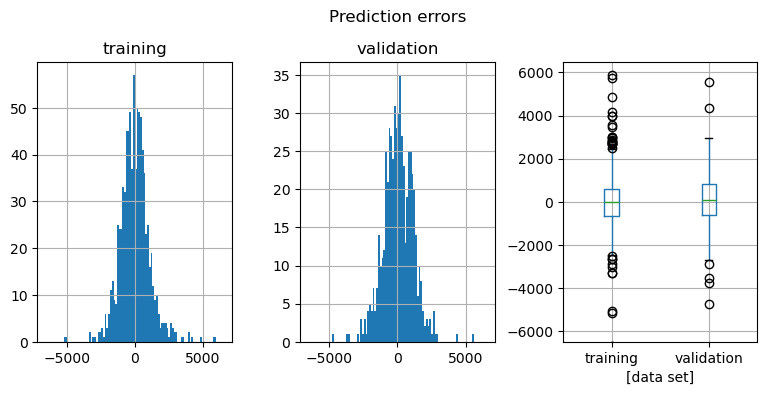

In [419]:
pred_error_train = pd.DataFrame({
    'residual': train_y - reg.predict(train_X), 
    'data set': 'training'
})
pred_error_valid = pd.DataFrame({
    'residual': valid_y - reg.predict(valid_X), 
    'data set': 'validation'
})
#boxdata_df = pred_error_train.append(pred_error_valid, ignore_index=True)
boxdata_df = pd.concat([pred_error_train, pred_error_valid], axis=0)
fig, axes = plt.subplots(nrows=1, ncols=3)
fig.set_size_inches(9, 4)
common = {'bins': 100, 'range': [-6500, 6500]}
pred_error_train.hist(ax=axes[0], **common)
pred_error_valid.hist(ax=axes[1], **common)
boxdata_df.boxplot(ax=axes[2], by='data set')

axes[0].set_title('training')
axes[1].set_title('validation')
axes[2].set_title(' ')
axes[2].set_ylim(-6500, 6500)
plt.suptitle('Prediction errors') 
plt.subplots_adjust(bottom=0.15, top=0.85, wspace=0.35)

plt.show()

In [421]:
boxdata_df.iloc[-1]

residual   -1048.185935
data set     validation
Name: 596, dtype: object

In [423]:
# sort the actual values in descending order of the prediction
# "gainsChart" and liftChart" are from DMBA, see Page 557
# reorder the predicted values in descending order and calculate the cumulative sum
pred_v = pd.Series(reg.predict(valid_X))
pred_v = pred_v.sort_values(ascending=False)
pred_v

34     26916.095816
174    23740.895466
519    22166.103042
569    21855.869942
252    21782.133511
           ...     
518     5282.235373
336     5151.788800
268     4954.704555
59      3600.518386
28     -1033.225248
Length: 575, dtype: float64

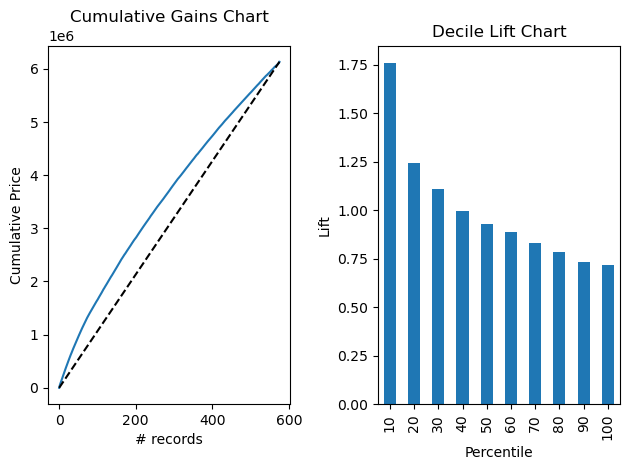

In [425]:
# sort the actual values in descending order of the prediction
df = pd.DataFrame({
    'predicted': reg.predict(valid_X),
    'actual': valid_y, 
})
df = df.sort_values(by=['predicted'], ascending=False)

fig, axes = plt.subplots(nrows=1, ncols=2)
ax = gainsChart(df['actual'], ax=axes[0])
ax.set_ylabel('Cumulative Price')
ax.set_title('Cumulative Gains Chart')

ax = liftChart(df['actual'], ax=axes[1], labelBars=False)
ax.set_ylabel('Lift')

plt.tight_layout()
plt.show()
# plt.savefig(DATA / 'ToyotaLift.png')

## Table 6.3

In [429]:
car_df = pd.read_csv(DATA / 'ToyotaCorolla.csv')
car_df

,Id,Model,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,Fuel_Type,HP,Met_Color,...,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
0,1,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13500,23,10,2002,46986,Diesel,90,1,...,1,1,0,0,0,1,0,0,0,0
1,2,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13750,23,10,2002,72937,Diesel,90,1,...,0,1,0,0,0,1,0,0,0,0
2,3,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13950,24,9,2002,41711,Diesel,90,1,...,0,1,0,0,0,1,0,0,0,0
3,4,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,14950,26,7,2002,48000,Diesel,90,0,...,0,1,0,0,0,1,0,0,0,0
4,5,TOYOTA Corolla 2.0 D4D HATCHB SOL 2/3-Doors,13750,30,3,2002,38500,Diesel,90,0,...,1,1,0,1,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1431,1438,TOYOTA Corolla 1.3 16V HATCHB G6 2/3-Doors,7500,69,12,1998,20544,Petrol,86,1,...,1,1,0,1,1,1,0,0,0,0
1432,1439,TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA 2/3-...,10845,72,9,1998,19000,Petrol,86,0,...,0,1,0,0,1,1,0,0,0,0
1433,1440,TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA 2/3-...,8500,71,10,1998,17016,Petrol,86,0,...,0,1,0,0,0,1,0,0,0,0
1434,1441,TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA 2/3-...,7250,70,11,1998,16916,Petrol,86,1,...,0,0,0,0,0,1,0,0,0,0


In [431]:
# Reduce data frame to the top 1000 rows and select columns for regression analysis
car_df = car_df.iloc[0:1000]

In [433]:
predictors = ['Age_08_04', 'KM', 'Fuel_Type', 'HP', 'Met_Color', 'Automatic', 'CC', 
              'Doors', 'Quarterly_Tax', 'Weight']
outcome = 'Price'

# partition data
X = pd.get_dummies(car_df[predictors], drop_first=True, dtype=int)
y = car_df[outcome]
train_X, valid_X, train_y, valid_y = train_test_split(X, y, test_size=0.4, random_state=1)

car_lm = LinearRegression()
car_lm.fit(train_X, train_y)

# print coefficients
print('intercept ', car_lm.intercept_)
print(pd.DataFrame({'Predictor': X.columns, 'coefficient': car_lm.coef_}))

# print performance measures
regressionSummary(train_y, car_lm.predict(train_X))

intercept  -1319.3543800411899
           Predictor  coefficient
0          Age_08_04  -140.748761
1                 KM    -0.017840
2                 HP    36.103419
3          Met_Color    84.281830
4          Automatic   416.781954
5                 CC     0.017737
6              Doors   -50.657863
7      Quarterly_Tax    13.625325
8             Weight    13.038711
9   Fuel_Type_Diesel  1066.464681
10  Fuel_Type_Petrol  2310.249543

Regression statistics

                      Mean Error (ME) : -0.0000
       Root Mean Squared Error (RMSE) : 1400.5823
            Mean Absolute Error (MAE) : 1046.9072
          Mean Percentage Error (MPE) : -1.0223
Mean Absolute Percentage Error (MAPE) : 9.2994


In [435]:
car_df

,Id,Model,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,Fuel_Type,HP,Met_Color,...,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
0,1,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13500,23,10,2002,46986,Diesel,90,1,...,1,1,0,0,0,1,0,0,0,0
1,2,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13750,23,10,2002,72937,Diesel,90,1,...,0,1,0,0,0,1,0,0,0,0
2,3,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13950,24,9,2002,41711,Diesel,90,1,...,0,1,0,0,0,1,0,0,0,0
3,4,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,14950,26,7,2002,48000,Diesel,90,0,...,0,1,0,0,0,1,0,0,0,0
4,5,TOYOTA Corolla 2.0 D4D HATCHB SOL 2/3-Doors,13750,30,3,2002,38500,Diesel,90,0,...,1,1,0,1,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1000,TOYOTA Corolla 1.6 16V HATCHB LINEA TERRA 2/3-...,9950,68,1,1999,42750,Petrol,110,1,...,0,1,0,0,0,1,0,0,0,0
996,1001,TOYOTA Corolla 1.6 16V LIFTB LINEA LUNA 4/5-Doors,9950,67,2,1999,42102,Petrol,110,1,...,1,1,0,1,0,1,1,0,0,0
997,1002,TOYOTA Corolla 1.6 LB Linea Terra 4/5-Doors,9950,63,6,1999,41586,Petrol,110,1,...,0,1,0,0,0,0,0,0,0,0
998,1003,TOYOTA Corolla 1.6 4/5-Doors,9900,64,5,1999,41200,Petrol,110,0,...,0,1,0,0,0,0,0,0,0,0


In [437]:
X

,Age_08_04,KM,HP,Met_Color,Automatic,CC,Doors,Quarterly_Tax,Weight,Fuel_Type_Diesel,Fuel_Type_Petrol
0,23,46986,90,1,0,2000,3,210,1165,1,0
1,23,72937,90,1,0,2000,3,210,1165,1,0
2,24,41711,90,1,0,2000,3,210,1165,1,0
3,26,48000,90,0,0,2000,3,210,1165,1,0
4,30,38500,90,0,0,2000,3,210,1170,1,0
...,...,...,...,...,...,...,...,...,...,...,...
995,68,42750,110,1,0,1600,3,69,1050,0,1
996,67,42102,110,1,0,1600,5,85,1075,0,1
997,63,41586,110,1,0,1600,5,19,1114,0,1
998,64,41200,110,0,0,1600,5,85,1070,0,1


In [439]:
pred_y = car_lm.predict(train_X)

print('adjusted r2 : ', adjusted_r2_score(train_y, pred_y, car_lm))
print('AIC : ', AIC_score(train_y, pred_y, car_lm))
print('BIC : ', BIC_score(train_y, pred_y, car_lm))

adjusted r2 :  0.8537958550253093
AIC :  10422.298278332171
BIC :  10479.45836384998


## Table 6.4

In [442]:
# Use predict() to make predictions on a new set
car_lm_pred = car_lm.predict(valid_X)

result = pd.DataFrame({'Predicted': car_lm_pred, 'Actual': valid_y,
                       'Residual': valid_y - car_lm_pred})
print(result.head(20))

# Compute common accuracy measures
regressionSummary(valid_y, car_lm_pred)

        Predicted  Actual     Residual
507  10607.333940   11500   892.666060
818   9272.705792    8950  -322.705792
452  10617.947808   11450   832.052192
368  13600.396275   11450 -2150.396275
242  12396.694660   11950  -446.694660
929   9496.498212    9995   498.501788
262  12480.063217   13500  1019.936783
810   8834.146068    7950  -884.146068
318  12183.361282    9900 -2283.361282
49   19206.965683   21950  2743.034317
446  10987.498309   11950   962.501691
142  18501.527375   19950  1448.472625
968   9914.690947    9950    35.309053
345  13827.299932   14950  1122.700068
971   7966.732543   10495  2528.267457
133  17185.242041   15950 -1235.242041
104  19952.658062   19450  -502.658062
6    16570.609280   16900   329.390720
600  13739.409113   11250 -2489.409113
496  11267.513740   11750   482.486260

Regression statistics

                      Mean Error (ME) : 103.6803
       Root Mean Squared Error (RMSE) : 1312.8523
            Mean Absolute Error (MAE) : 1017.5972
        

## Figure 6.1
Determine the residuals and create a histogram

0.7425


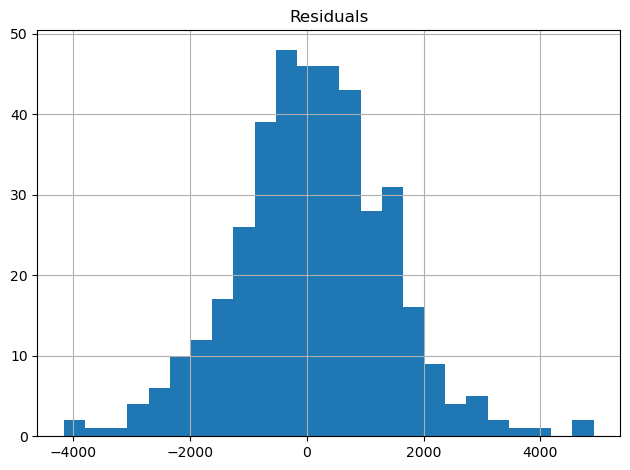

In [445]:
car_lm_pred = car_lm.predict(valid_X)
all_residuals = valid_y - car_lm_pred

# Determine the percentage of datapoints with a residual in [-1406, 1406] = approx. 75\%
print(len(all_residuals[(all_residuals > -1406) & (all_residuals < 1406)]) / len(all_residuals))

ax = pd.DataFrame({'Residuals': all_residuals}).hist(bins=25)

plt.tight_layout()
plt.show()

## Table 6.5
Run an <b>exhaustive search</b>. The Fuel type column is categorical and needs to be converted into dummy variables.

In [448]:
def train_model(variables):
    model = LinearRegression()
    model.fit(train_X[variables], train_y)
    return model

def score_model(model, variables):
    pred_y = model.predict(train_X[variables])
    # we negate as score is optimized to be as low as possible
    return -adjusted_r2_score(train_y, pred_y, model)

allVariables = train_X.columns
results = exhaustive_search(allVariables, train_model, score_model)

data = []
for result in results:
    model = result['model']
    variables = result['variables']
    AIC = AIC_score(train_y, model.predict(train_X[variables]), model)
    
    d = {'n': result['n'], 'r2adj': -result['score'], 'AIC': AIC}
    d.update({var: var in result['variables'] for var in allVariables})
    data.append(d)
pd.set_option('display.width', 100)
print(pd.DataFrame(data, columns=('n', 'r2adj', 'AIC') + tuple(sorted(allVariables))))
pd.reset_option('display.width')

     n     r2adj           AIC  Age_08_04  Automatic     CC  Doors  Fuel_Type_Diesel  \
0    1  0.767901  10689.712094       True      False  False  False             False   
1    2  0.801160  10597.910645       True      False  False  False             False   
2    3  0.829659  10506.084235       True      False  False  False             False   
3    4  0.846357  10445.174820       True      False  False  False             False   
4    5  0.849044  10435.578836       True      False  False  False             False   
5    6  0.853172  10419.932278       True      False  False  False             False   
6    7  0.853860  10418.104025       True      False  False  False              True   
7    8  0.854297  10417.290103       True       True  False  False              True   
8    9  0.854172  10418.789079       True       True  False   True              True   
9   10  0.854036  10420.330800       True       True  False   True              True   
10  11  0.853796  10422.298278  

## Table 6.6 Backward elimination

In [450]:
def train_model(variables):
    model = LinearRegression()
    model.fit(train_X[variables], train_y)
    return model

def score_model(model, variables):
    return AIC_score(train_y, model.predict(train_X[variables]), model)

best_model, best_variables = backward_elimination(train_X.columns, train_model, score_model, verbose=True)

print(best_variables)

Variables: Age_08_04, KM, HP, Met_Color, Automatic, CC, Doors, Quarterly_Tax, Weight, Fuel_Type_Diesel, Fuel_Type_Petrol
Start: score=10422.30
Step: score=10420.33, remove CC
Step: score=10418.79, remove Met_Color
Step: score=10417.29, remove Doors
Step: score=10417.29, remove None
['Age_08_04', 'KM', 'HP', 'Automatic', 'Quarterly_Tax', 'Weight', 'Fuel_Type_Diesel', 'Fuel_Type_Petrol']


In [451]:
regressionSummary(valid_y, best_model.predict(valid_X[best_variables]))


Regression statistics

                      Mean Error (ME) : 103.3045
       Root Mean Squared Error (RMSE) : 1314.4844
            Mean Absolute Error (MAE) : 1016.8875
          Mean Percentage Error (MPE) : -0.2700
Mean Absolute Percentage Error (MAPE) : 8.9984


## Table 6.7 Forward selection

In [456]:
# The initial model is the constant model - this requires special handling
# in train_model and score_model
def train_model(variables):
    if len(variables) == 0:
        return None
    model = LinearRegression()
    model.fit(train_X[variables], train_y)
    return model

def score_model(model, variables):
    if len(variables) == 0:
        return AIC_score(train_y, [train_y.mean()] * len(train_y), model, df=1)
    return AIC_score(train_y, model.predict(train_X[variables]), model)

best_model, best_variables = forward_selection(train_X.columns, train_model, score_model, verbose=True)

print(best_variables)

Variables: Age_08_04, KM, HP, Met_Color, Automatic, CC, Doors, Quarterly_Tax, Weight, Fuel_Type_Diesel, Fuel_Type_Petrol
Start: score=11565.07, constant
Step: score=10689.71, add Age_08_04
Step: score=10597.91, add HP
Step: score=10506.08, add Weight
Step: score=10445.17, add KM
Step: score=10435.58, add Quarterly_Tax
Step: score=10419.93, add Fuel_Type_Petrol
Step: score=10418.10, add Fuel_Type_Diesel
Step: score=10417.29, add Automatic
Step: score=10417.29, add None
['Age_08_04', 'HP', 'Weight', 'KM', 'Quarterly_Tax', 'Fuel_Type_Petrol', 'Fuel_Type_Diesel', 'Automatic']


## Table 6.8 Stepwise regression

In [459]:
best_model, best_variables = stepwise_selection(train_X.columns, train_model, score_model, verbose=True)

print(best_variables)

Variables: Age_08_04, KM, HP, Met_Color, Automatic, CC, Doors, Quarterly_Tax, Weight, Fuel_Type_Diesel, Fuel_Type_Petrol
Start: score=11565.07, constant
Step: score=10689.71, add Age_08_04
Step: score=10597.91, add HP
Step: score=10506.08, add Weight
Step: score=10445.17, add KM
Step: score=10435.58, add Quarterly_Tax
Step: score=10419.93, add Fuel_Type_Petrol
Step: score=10418.10, add Fuel_Type_Diesel
Step: score=10417.29, add Automatic
Step: score=10417.29, unchanged None
['Age_08_04', 'HP', 'Weight', 'KM', 'Quarterly_Tax', 'Fuel_Type_Petrol', 'Fuel_Type_Diesel', 'Automatic']


## Fit regression using the selected predictors

In [462]:
# predictors and outcome
predictors = ['Age_08_04', 'HP', 'Weight', 'KM', 'Quarterly_Tax', 'Fuel_Type_Petrol', 'Fuel_Type_Diesel', 'Automatic']
outcome = 'Price'
X = train_X[predictors]
y = train_y

# fit the regression model y on x
best_lm = LinearRegression()
best_lm.fit(X,y)

# print coefficients
print('intercept ', best_lm.intercept_)
print(pd.DataFrame({'Predictor': X.columns, 'coefficient': best_lm.coef_}))

# print performance measures (training set)
print("\nModel performance on training data:")
regressionSummary(train_y, best_lm.predict(train_X[predictors]))

# predict prices in validation set, print first few predicted/actual values and residuals
best_lm_pred = best_lm.predict(valid_X[predictors])

# print performance measures (validation set)
print("\nModel performance on validation data:")
regressionSummary(valid_y, best_lm_pred)

intercept  -1077.5187647890834
          Predictor  coefficient
0         Age_08_04  -140.980525
1                HP    36.261765
2            Weight    12.739357
3                KM    -0.017939
4     Quarterly_Tax    13.485201
5  Fuel_Type_Petrol  2277.107559
6  Fuel_Type_Diesel  1086.402937
7         Automatic   425.428022

Model performance on training data:

Regression statistics

                      Mean Error (ME) : -0.0000
       Root Mean Squared Error (RMSE) : 1401.7404
            Mean Absolute Error (MAE) : 1049.5729
          Mean Percentage Error (MPE) : -1.0240
Mean Absolute Percentage Error (MAPE) : 9.3264

Model performance on validation data:

Regression statistics

                      Mean Error (ME) : 103.3045
       Root Mean Squared Error (RMSE) : 1314.4844
            Mean Absolute Error (MAE) : 1016.8875
          Mean Percentage Error (MPE) : -0.2700
Mean Absolute Percentage Error (MAPE) : 8.9984


## Table 6.9 Regularized methods

## Ridge and Lasso regression uses two different penalty functions. Ridge uses L2 where as lasso go with L1. In ridge regression, the penalty is the sum of the squares of the coefficients and for the Lasso, it's the sum of the absolute values of the coefficients. It's a shrinkage towards zero using an absolute value (L1 penalty) rather than a sum of squares(L2 penalty).
## As we know that ridge regression can't have zero coefficients. Here, we can either select all the coefficients or none of them whereas LASSO does both parameter shrinkage and variable selection automatically because it zero out the co-efficients of collinear variables. Here it helps to select the variables) out of given n variables while performing lasso regression.

## Lasso Regression

In [21]:
car_df = pd.read_csv(DATA / 'ToyotaCorolla.csv')

# create a list of predictor variables by remvoing output variables and text columns
excludeColumns = ('Price', 'Id', 'Model', 'Fuel_Type', 'Color')
# list comprehension
predictors = [s for s in car_df.columns if s not in excludeColumns]
outcome = 'Price'

# partition data
X = car_df[predictors]
y = car_df[outcome]
train_X, valid_X, train_y, valid_y = train_test_split(X, y, test_size=0.4, random_state=1)

### Standardize predictors based on training data

### Fit LassoCV to standardized predictors by filling in the missing parts below

In [22]:
# see https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LassoCV.html
lasso_cv = LassoCV(max_iter=10000, alphas=np.logspace(-3, 3, 100), random_state=1, cv=5)
# It's better to choose a range that spans several orders of magnitude, e.g., 
# alphas=np.logspace(-3, 3, 100) or 100 values of alpha ranging from 0.001 to 1000 spaced logarithmically.
# lasso_cv = LassoCV(max_iter=10000,random_state=1, cv=5)
# 100 alphas values are generated automatically by default

In [ ]:
lasso_cv.fit( , )

### Find Root Mean Squared Error (RMSE) by filling in the missing parts below

In [ ]:
regressionSummary( , )

### Print out the chosen alpha and coefficients

In [ ]:
print('Lasso-CV chosen regularization: ', lasso_cv['model'].alpha_)
print(lasso_cv['model'].coef_)

### Fit Lasso by plugging in the chosen alpha below into Lasso() 

In [ ]:
lasso = Lasso(max_iter=10000,random_state=1, alpha= )
lasso.fit(train_X_standardized, train_y)

### Print out the Lasso coefficients

In [ ]:
print(lasso.coef_)

### Find Root Mean Squared Error (RMSE) by filling in the missing parts below

In [ ]:
regressionSummary( , lasso.predict())

## Use Pipeline to fit Lasso

In [601]:
car_df = pd.read_csv(DATA / 'ToyotaCorolla.csv')

# create a list of predictor variables by remvoing output variables and text columns
excludeColumns = ('Price', 'Id', 'Model', 'Fuel_Type', 'Color')
# list comprehension
predictors = [s for s in car_df.columns if s not in excludeColumns]
outcome = 'Price'

# partition data
X = car_df[predictors]
y = car_df[outcome]
train_X, valid_X, train_y, valid_y = train_test_split(X, y, test_size=0.4, random_state=1)

In [603]:
X.columns

Index(['Age_08_04', 'Mfg_Month', 'Mfg_Year', 'KM', 'HP', 'Met_Color',
       'Automatic', 'CC', 'Doors', 'Cylinders', 'Gears', 'Quarterly_Tax',
       'Weight', 'Mfr_Guarantee', 'BOVAG_Guarantee', 'Guarantee_Period', 'ABS',
       'Airbag_1', 'Airbag_2', 'Airco', 'Automatic_airco', 'Boardcomputer',
       'CD_Player', 'Central_Lock', 'Powered_Windows', 'Power_Steering',
       'Radio', 'Mistlamps', 'Sport_Model', 'Backseat_Divider', 'Metallic_Rim',
       'Radio_cassette', 'Parking_Assistant', 'Tow_Bar'],
      dtype='object')

In [605]:
# see https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LassoCV.html
# default choose one alpha from 100 different values of the regularization strength parameter α),
# logarithmically spaced between a maximum and minimum value that it computes from your data.
lasso_cv = Pipeline([
    ['normalize', StandardScaler(with_mean=True)],
    ['model', LassoCV(max_iter=10000,random_state=1, cv=5)],
])
lasso_cv.fit(train_X, train_y)
regressionSummary(valid_y, lasso_cv.predict(valid_X))
print('Lasso-CV chosen regularization: ', lasso_cv['model'].alpha_)
print(lasso_cv['model'].coef_)


Regression statistics

                      Mean Error (ME) : 91.5893
       Root Mean Squared Error (RMSE) : 1300.2457
            Mean Absolute Error (MAE) : 870.7886
          Mean Percentage Error (MPE) : -0.0677
Mean Absolute Percentage Error (MAPE) : 8.7925
Lasso-CV chosen regularization:  9.37295141260461
[-336.37844533   -0.         1920.22327957 -661.0374952   430.45771764
   -8.2045801   118.06293758 -219.92729857  101.66371156    0.
    7.95584937  460.90898836  512.27429188   69.27075953   86.01574711
  184.10034949  -78.29167076   63.51035553   -7.03264523   43.43201849
  580.03850624 -118.28627631   80.62655981   82.43617808  119.54849976
  -65.59327946    5.02683997   -7.3566037   182.00082116   -7.73634434
  120.72555326    0.           -4.71328366  -67.11426696]


### Fit lasso again by pluggin in the chosen alpha and compare results

In [ ]:
lasso = Pipeline([
    ['normalize', StandardScaler(with_mean=True)],
    ['model', Lasso(max_iter=10000,random_state=1, alpha=9.37295141260461)],
])
lasso.fit(train_X, train_y)
print(lasso['model'].coef_)
regressionSummary(valid_y, lasso.predict(valid_X))

## Ridge Regression

In [24]:
car_df = pd.read_csv(DATA / 'ToyotaCorolla.csv')

# create a list of predictor variables by remvoing output variables and text columns
excludeColumns = ('Price', 'Id', 'Model', 'Fuel_Type', 'Color')
# list comprehension
predictors = [s for s in car_df.columns if s not in excludeColumns]
outcome = 'Price'

# partition data
X = car_df[predictors]
y = car_df[outcome]
train_X, valid_X, train_y, valid_y = train_test_split(X, y, test_size=0.4, random_state=1)

### Standardize predictors based on training data

### Fit RidgeCV() to standardized predictors by filling in the missing parts below

In [ ]:
# see https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.RidgeCV.html#sklearn.linear_model.RidgeCV
ridge_cv = RidgeCV(alphas=np.logspace(-3, 3, 100), cv=5)
# default alphas=(0.1, 1.0, 10.0), only 3 values
# It's better to choose a range that spans several orders of magnitude, e.g., 
# alphas=np.logspace(-3, 3, 100) or 100 values of alpha ranging from 0.001 to 1000 spaced logarithmically.
ridge_cv.fit( ,  )

### Find Root Mean Squared Error (RMSE) by filling in the missing parts below

In [ ]:
regressionSummary( , )

### Print out the chosen alpha and coefficients

In [ ]:
print('Ridge-CV chosen regularization: ', ridge_cv.alpha_)
print(ridge_cv.coef_)

### Fit Ridge Regression by plugging in the chosen alpha below into Ridge() 

In [ ]:
ridge = Ridge(max_iter=10000,random_state=1, alpha= )
ridge.fit(train_X_standardized, train_y)

### Print out the Ridge Regression coefficients

In [ ]:
print(ridge_.coef_)

### Find Root Mean Squared Error (RMSE) by filling in the missing parts below

In [ ]:
regressionSummary( , )

## Use Pipeline to fit Ridge Regression

In [538]:
car_df = pd.read_csv(DATA / 'ToyotaCorolla.csv')

# create a list of predictor variables by remvoing output variables and text columns
excludeColumns = ('Price', 'Id', 'Model', 'Fuel_Type', 'Color')
# list comprehension
predictors = [s for s in car_df.columns if s not in excludeColumns]
outcome = 'Price'

# partition data
X = car_df[predictors]
y = car_df[outcome]
train_X, valid_X, train_y, valid_y = train_test_split(X, y, test_size=0.4, random_state=1)

In [540]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
#from patsy import dmatrices

In [ ]:
# see https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.RidgeCV.html#sklearn.linear_model.RidgeCV
ridge_cv = Pipeline([
    ['normalize', StandardScaler(with_mean=True)],
    ['model', RidgeCV(alphas=np.logspace(-3, 3, 100), cv=5)],
])
ridge_cv.fit(train_X, train_y)
regressionSummary(valid_y, ridge_cv.predict(valid_X))
print('Ridge-CV chosen regularization: ', ridge_cv['model'].alpha_)
print(ridge_cv['model'].coef_)

### Fit ridge again by plugging in the chosen alpha and compare results

In [ ]:
ridge = Pipeline([
    ['normalize', StandardScaler(with_mean=True)],
    ['model', Ridge(max_iter=10000, random_state=1, alpha= )]
])
ridge.fit(train_X, train_y)
print(ridge['model'].coef_)
regressionSummary(valid_y, ridge.predict(valid_X))

### The results should match with or without using Pipeline.

# Regularization (Shrinkage Models) - Elastic Net

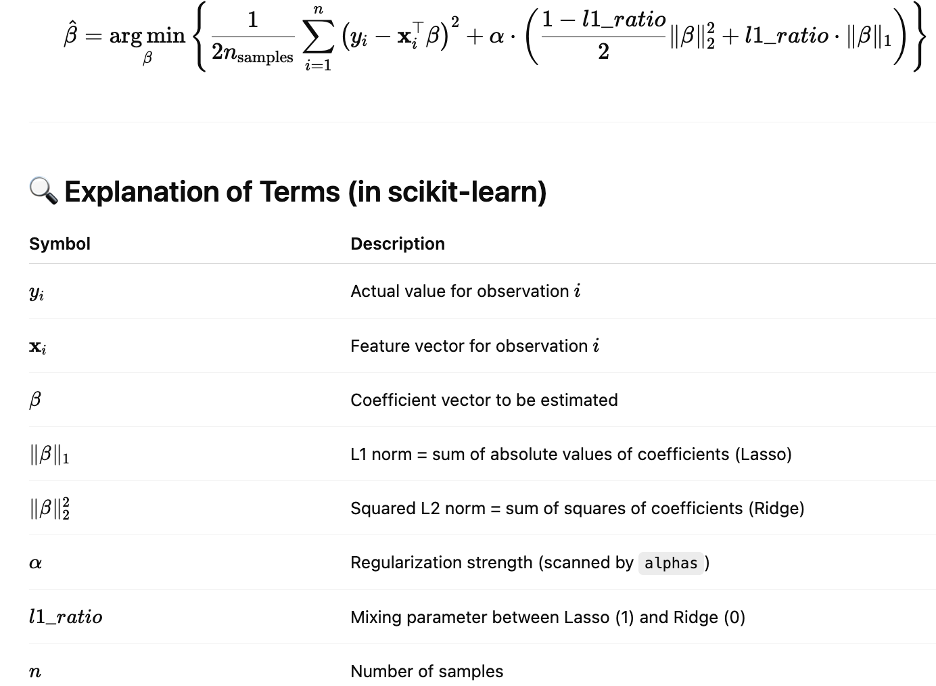

In [1]:
# Do not run the code in this cell on your computer or the equation below may disappear
from IPython.display import Image
import base64

with open("/Users/limin/Downloads/ElasticNet.png", "rb") as f:
    img_data = base64.b64encode(f.read()).decode("utf-8")

display(Image(data=base64.b64decode(img_data)))

<b>alpha</b>: Controls the overall strength of regularization

<b>l1_ratio</b>: Controls the mix between L1 (Lasso) and L2 (Ridge)

<b>l1_ratio = 1</b> → Lasso

<b>l1_ratio = 0</b> → Ridge

<b>0 < l1_ratio < 1</b> → Elastic Net

In [2]:
from sklearn.linear_model import ElasticNetCV
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, root_mean_squared_error
import numpy as np

In [3]:
# 1. Generate synthetic regression data
X, y = make_regression(n_samples=1000, n_features=20, noise=10, random_state=1)

In [4]:
X.shape

(1000, 20)

In [5]:
y.shape

(1000,)

In [6]:
# 2. Split data into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=1)

In [7]:
# 3. Set up a pipeline with standardization and ElasticNetCV
model = Pipeline([
    ('scaler', StandardScaler()),
    ('elasticnet', ElasticNetCV(cv=5, alphas=np.logspace(-3, 3, 100), l1_ratio=np.arange(0.1, 1, 0.05), random_state=1))
])

In [8]:
# 4. Fit the model
model.fit(X_train, y_train)

,steps,"[('scaler', ...), ('elasticnet', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,l1_ratio,"array([0.1 , ..., 0.9 , 0.95])"
,eps,0.001
,n_alphas,'deprecated'
,alphas,array([1.0000...00000000e+03])


In [9]:
# 5. Predict and evaluate
y_pred = model.predict(X_test)
print("R² Score:", r2_score(y_test, y_pred))
print("RMSE:", root_mean_squared_error(y_test, y_pred))

R² Score: 0.9958047173172199
RMSE: 9.99592213209025


In [10]:
# 6. Extract best alpha and l1_ratio
best_model = model.named_steps['elasticnet']
print("Best alpha:", best_model.alpha_)
print("Best l1_ratio:", best_model.l1_ratio_)

Best alpha: 0.03274549162877728
Best l1_ratio: 0.9500000000000003


In [11]:
print('Coefficients: \n', model['elasticnet'].coef_)

Coefficients: 
 [ 7.44684085e+01  4.70024453e-02 -1.40836501e-01  5.35581042e+00
  2.72836040e+01  8.22681720e+01  3.55383524e+01  3.03342051e+01
 -6.97384419e-01 -1.19010939e-02 -6.41621293e-01  9.26125309e+00
  1.45768947e-01  2.12347963e-01 -7.23683452e-01  4.84595230e+01
  7.11200632e+01 -1.94339208e-01  2.34948431e-01  4.00752613e+01]


## Bayesian Ridge Regression

In [70]:
# see https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.BayesianRidge.html#sklearn.linear_model.BayesianRidge
bayesianRidge = Pipeline([
    ['normalize', StandardScaler()],
    ['model', BayesianRidge()],
])
bayesianRidge.fit(train_X, train_y)
regressionSummary(valid_y, bayesianRidge.predict(valid_X))
print('Bayesian ridge chosen regularization: ', 
      bayesianRidge['model'].lambda_ / bayesianRidge['model'].alpha_)


Regression statistics

                      Mean Error (ME) : 105.5382
       Root Mean Squared Error (RMSE) : 1313.0217
            Mean Absolute Error (MAE) : 1017.2356
          Mean Percentage Error (MPE) : -0.2703
Mean Absolute Percentage Error (MAPE) : 9.0012
Bayesian ridge chosen regularization:  2.7737000643213903


In [71]:
linearRegression = Pipeline([
    ['normalize', StandardScaler()],
    ['model', LinearRegression()],
])
linearRegression.fit(train_X, train_y)
regressionSummary(valid_y, linearRegression.predict(valid_X))


Regression statistics

                      Mean Error (ME) : 103.6803
       Root Mean Squared Error (RMSE) : 1312.8523
            Mean Absolute Error (MAE) : 1017.5972
          Mean Percentage Error (MPE) : -0.2633
Mean Absolute Percentage Error (MAPE) : 9.0111


In [72]:
pd.DataFrame({
    'features': train_X.columns, 
    'linear regression': linearRegression['model'].coef_, 
    'lassoCV': lasso_cv['model'].coef_, 
    'ridgeCV': ridge_cv['model'].coef_, 
    'bayesianRidge': bayesianRidge['model'].coef_,
})

,features,linear regression,lassoCV,ridgeCV,bayesianRidge
0,Age_08_04,-2346.564908,-2344.727331,-2288.858266,-2329.981222
1,KM,-640.646815,-638.648217,-675.364958,-651.107146
2,HP,550.253745,509.868470,538.934943,546.483948
3,Met_Color,39.094012,0.000000,40.787291,39.468401
4,Automatic,96.361895,44.374033,90.379723,94.470139
5,CC,10.966581,0.000000,16.229287,12.616316
6,Doors,-47.961759,-0.000000,-38.893229,-45.367365
7,Quarterly_Tax,610.016332,299.727393,559.496246,594.107204
8,Weight,770.715576,757.837467,784.202771,775.190239
9,Fuel_Type_Diesel,358.655735,-0.000000,248.289270,321.365335


## Table 6.10

In [73]:
# run a linear regression of Price on the remaining 11 predictors in the training set using STATSMODELS
car_df = pd.read_csv(DATA / 'ToyotaCorolla.csv')
var = ['Age_08_04', 'KM', 'Fuel_Type', 'HP', 'Met_Color', 'Automatic', 'CC', 
              'Doors', 'Quarterly_Tax', 'Weight', 'Price']
predictors = ['Age_08_04', 'KM', 'Fuel_Type', 'HP', 'Met_Color', 'Automatic', 'CC', 
              'Doors', 'Quarterly_Tax', 'Weight']
# partition data
df = pd.get_dummies(car_df[var], drop_first=True, dtype=int)
train, valid = train_test_split(df, test_size=0.4, random_state=1)

In [74]:
train.dtypes

Age_08_04           int64
KM                  int64
HP                  int64
Met_Color           int64
Automatic           int64
CC                  int64
Doors               int64
Quarterly_Tax       int64
Weight              int64
Price               int64
Fuel_Type_Diesel    int64
Fuel_Type_Petrol    int64
dtype: object

In [75]:
train.drop(['Price'], axis=1)

,Age_08_04,KM,HP,Met_Color,Automatic,CC,Doors,Quarterly_Tax,Weight,Fuel_Type_Diesel,Fuel_Type_Petrol
1238,75,82256,110,1,0,1600,3,69,1050,0,1
1085,79,131500,72,0,0,2000,5,185,1140,1,0
680,61,102106,110,0,0,1600,3,69,1050,0,1
593,50,22648,97,1,0,1400,5,85,1060,0,1
647,68,117000,72,0,0,2000,3,185,1115,1,0
...,...,...,...,...,...,...,...,...,...,...,...
715,62,90000,110,0,0,1600,3,69,1050,0,1
905,65,59000,110,0,0,1600,3,69,1050,0,1
1096,75,125400,110,0,0,1600,3,69,1050,0,1
235,38,60829,110,1,0,1600,5,85,1075,0,1


In [76]:
train

,Age_08_04,KM,HP,Met_Color,Automatic,CC,Doors,Quarterly_Tax,Weight,Price,Fuel_Type_Diesel,Fuel_Type_Petrol
1238,75,82256,110,1,0,1600,3,69,1050,7750,0,1
1085,79,131500,72,0,0,2000,5,185,1140,7950,1,0
680,61,102106,110,0,0,1600,3,69,1050,7950,0,1
593,50,22648,97,1,0,1400,5,85,1060,10950,0,1
647,68,117000,72,0,0,2000,3,185,1115,6950,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
715,62,90000,110,0,0,1600,3,69,1050,8490,0,1
905,65,59000,110,0,0,1600,3,69,1050,9950,0,1
1096,75,125400,110,0,0,1600,3,69,1050,7900,0,1
235,38,60829,110,1,0,1600,5,85,1075,11650,0,1


In [77]:
formula = 'Price ~ ' + ' + '.join(train.drop(['Price'], axis=1).columns)

car_lm = smf.ols(formula=formula, data=train).fit()
print(car_lm.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.874
Model:                            OLS   Adj. R-squared:                  0.872
Method:                 Least Squares   F-statistic:                     535.5
Date:                Mon, 09 Jun 2025   Prob (F-statistic):               0.00
Time:                        11:12:02   Log-Likelihood:                -7405.4
No. Observations:                 861   AIC:                         1.483e+04
Df Residuals:                     849   BIC:                         1.489e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept         -258.6042   1551.111  

## Diamonds example

In [93]:
# install openpyxl, A Python library to read/write Excel 2010 xlsx/xlsm files 
# pip install openpyxl

In [95]:
diamonds = pd.read_excel(DATA / '19_diamonds.xlsx')
diamonds

,Price,Weight (carats)
0,923,0.45
1,1034,0.45
2,1071,0.45
3,1313,0.46
4,1028,0.38
...,...,...
88,1347,0.50
89,1313,0.50
90,1378,0.50
91,1604,0.50


In [97]:
diamonds.columns = [s.strip().replace(' ', '_') for s in diamonds.columns]
diamonds.columns = [s.strip().replace('(', '') for s in diamonds.columns]
diamonds.columns = [s.strip().replace(')', '') for s in diamonds.columns]
diamonds

,Price,Weight_carats
0,923,0.45
1,1034,0.45
2,1071,0.45
3,1313,0.46
4,1028,0.38
...,...,...
88,1347,0.50
89,1313,0.50
90,1378,0.50
91,1604,0.50


In [99]:
diamonds.corr()

,Price,Weight_carats
Price,1.000000,0.713151
Weight_carats,0.713151,1.000000


In [101]:
diamonds.cov()

,Price,Weight_carats
Price,42241.476391,7.964904
Weight_carats,7.964904,0.002953


In [103]:
diamonds_lm = smf.ols(formula='Price ~ Weight_carats', data=diamonds).fit()
diamonds_lm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Price   R-squared:                       0.509
Model:                            OLS   Adj. R-squared:                  0.503
Method:                 Least Squares   F-statistic:                     94.18
Date:                Tue, 02 Jul 2024   Prob (F-statistic):           1.06e-15
Time:                        21:48:50   Log-Likelihood:                -593.70
No. Observations:                  93   AIC:                             1191.
Df Residuals:                      91   BIC:                             1196.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        15.2000    114.791      0.132      0.895    -212.819     243.219
Weight_carats  2697.2532    277.935      9.705      0.000    2145.169    3249.338
==============================================================================
Omnibus:                        3.353   Durbin-Watson:                   0.987
Prob(Omnibus):                  0.187   Jarque-Bera (JB):                3.155
Skew:                           0.383   Prob(JB):                        0.207
Kurtosis:                       2.523   Cond. No.                         21.6
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [105]:
# Create a data frame for a nex X
NewData = pd.DataFrame([{'Weight_carats': 0.5}])
NewData

,Weight_carats
0,0.5


In [107]:
# Confidence interval for the mean value of Y given a new X: mean_ci_lower  mean_ci_upper
# Prediction interval for the individual value of Y given a new X: obs_ci_lower obs_ci_upper
print(diamonds_lm.get_prediction(NewData, weights=1).summary_frame())

          mean   mean_se  mean_ci_lower  mean_ci_upper  obs_ci_lower  \
0  1363.826578  29.30641    1305.612996    1422.040161   1070.238354   

   obs_ci_upper  
0   1657.414802  


# Linear regression diagnostics

In [110]:
# code for Linear regression diagnostics
import statsmodels
import statsmodels.formula.api as smf
import pandas as pd
import numpy as np
import seaborn as sns
from statsmodels.tools.tools import maybe_unwrap_results
from statsmodels.graphics.gofplots import ProbPlot
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
from typing import Type

style_talk = 'seaborn-talk'    #refer to plt.style.available

class Linear_Reg_Diagnostic():
    """
    Diagnostic plots to identify potential problems in a linear regression fit.
    Mainly,
        a. non-linearity of data
        b. Correlation of error terms
        c. non-constant variance
        d. outliers
        e. high-leverage points
        f. collinearity

    Author:
        Prajwal Kafle (p33ajkafle@gmail.com, where 3 = r)
        Does not come with any sort of warranty.
        Please test the code one your end before using.
    """

    def __init__(self,
                 results: Type[statsmodels.regression.linear_model.RegressionResultsWrapper]) -> None:
        """
        For a linear regression model, generates following diagnostic plots:

        a. residual
        b. qq
        c. scale location and
        d. leverage

        and a table

        e. vif

        Args:
            results (Type[statsmodels.regression.linear_model.RegressionResultsWrapper]):
                must be instance of statsmodels.regression.linear_model object

        Raises:
            TypeError: if instance does not belong to above object

        Example:
        >>> import numpy as np
        >>> import pandas as pd
        >>> import statsmodels.formula.api as smf
        >>> x = np.linspace(-np.pi, np.pi, 100)
        >>> y = 3*x + 8 + np.random.normal(0,1, 100)
        >>> df = pd.DataFrame({'x':x, 'y':y})
        >>> res = smf.ols(formula= "y ~ x", data=df).fit()
        >>> cls = Linear_Reg_Diagnostic(res)
        >>> cls(plot_context="seaborn-paper")

        In case you do not need all plots you can also independently make an individual plot/table
        in following ways

        >>> cls = Linear_Reg_Diagnostic(res)
        >>> cls.residual_plot()
        >>> cls.qq_plot()
        >>> cls.scale_location_plot()
        >>> cls.leverage_plot()
        >>> cls.vif_table()
        """

        if isinstance(results, statsmodels.regression.linear_model.RegressionResultsWrapper) is False:
            raise TypeError("result must be instance of statsmodels.regression.linear_model.RegressionResultsWrapper object")

        self.results = maybe_unwrap_results(results)

        self.y_true = self.results.model.endog
        self.y_predict = self.results.fittedvalues
        self.xvar = self.results.model.exog
        self.xvar_names = self.results.model.exog_names

        self.residual = np.array(self.results.resid)
        influence = self.results.get_influence()
        self.residual_norm = influence.resid_studentized_internal
        self.leverage = influence.hat_matrix_diag
        self.cooks_distance = influence.cooks_distance[0]
        self.nparams = len(self.results.params)

    def __call__(self, plot_context='seaborn-paper'):
        # print(plt.style.available)
        with plt.style.context(plot_context):
            fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10,10))
            self.residual_plot(ax=ax[0,0])
            self.qq_plot(ax=ax[0,1])
            self.scale_location_plot(ax=ax[1,0])
            self.leverage_plot(ax=ax[1,1])
            plt.show()

        self.vif_table()
        return fig, ax


    def residual_plot(self, ax=None):
        """
        Residual vs Fitted Plot

        Graphical tool to identify non-linearity.
        (Roughly) Horizontal red line is an indicator that the residual has a linear pattern
        """
        if ax is None:
            fig, ax = plt.subplots()

        sns.residplot(
            x=self.y_predict,
            y=self.residual,
            lowess=True,
            scatter_kws={'alpha': 0.5},
            line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8},
            ax=ax)

        # annotations
        residual_abs = np.abs(self.residual)
        abs_resid = np.flip(np.sort(residual_abs))
        abs_resid_top_3 = abs_resid[:3]
        for i, _ in enumerate(abs_resid_top_3):
            ax.annotate(
                i,
                xy=(self.y_predict[i], self.residual[i]),
                color='C3')

        ax.set_title('Residuals vs Fitted', fontweight="bold")
        ax.set_xlabel('Fitted values')
        ax.set_ylabel('Residuals')
        return ax

    def qq_plot(self, ax=None):
        """
        Standarized Residual vs Theoretical Quantile plot

        Used to visually check if residuals are normally distributed.
        Points spread along the diagonal line will suggest so.
        """
        if ax is None:
            fig, ax = plt.subplots()

        QQ = ProbPlot(self.residual_norm)
        QQ.qqplot(line='45', alpha=0.5, lw=1, ax=ax)

        # annotations
        abs_norm_resid = np.flip(np.argsort(np.abs(self.residual_norm)), 0)
        abs_norm_resid_top_3 = abs_norm_resid[:3]
        for r, i in enumerate(abs_norm_resid_top_3):
            ax.annotate(
                i,
                xy=(np.flip(QQ.theoretical_quantiles, 0)[r], self.residual_norm[i]),
                ha='right', color='C3')

        ax.set_title('Normal Q-Q', fontweight="bold")
        ax.set_xlabel('Theoretical Quantiles')
        ax.set_ylabel('Standardized Residuals')
        return ax

    def scale_location_plot(self, ax=None):
        """
        Sqrt(Standarized Residual) vs Fitted values plot

        Used to check homoscedasticity of the residuals.
        Horizontal line will suggest so.
        """
        if ax is None:
            fig, ax = plt.subplots()

        residual_norm_abs_sqrt = np.sqrt(np.abs(self.residual_norm))

        ax.scatter(self.y_predict, residual_norm_abs_sqrt, alpha=0.5);
        sns.regplot(
            x=self.y_predict,
            y=residual_norm_abs_sqrt,
            scatter=False, ci=False,
            lowess=True,
            line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8},
            ax=ax)

        # annotations
        abs_sq_norm_resid = np.flip(np.argsort(residual_norm_abs_sqrt), 0)
        abs_sq_norm_resid_top_3 = abs_sq_norm_resid[:3]
        for i in abs_sq_norm_resid_top_3:
            ax.annotate(
                i,
                xy=(self.y_predict[i], residual_norm_abs_sqrt[i]),
                color='C3')
        ax.set_title('Scale-Location', fontweight="bold")
        ax.set_xlabel('Fitted values')
        ax.set_ylabel(r'$\sqrt{|\mathrm{Standardized\ Residuals}|}$');
        return ax

    def leverage_plot(self, ax=None):
        """
        Residual vs Leverage plot

        Points falling outside Cook's distance curves are considered observation that can sway the fit
        aka are influential.
        Good to have none outside the curves.
        """
        if ax is None:
            fig, ax = plt.subplots()

        ax.scatter(
            self.leverage,
            self.residual_norm,
            alpha=0.5);

        sns.regplot(
            x=self.leverage,
            y=self.residual_norm,
            scatter=False,
            ci=False,
            lowess=True,
            line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8},
            ax=ax)

        # annotations
        leverage_top_3 = np.flip(np.argsort(self.cooks_distance), 0)[:3]
        for i in leverage_top_3:
            ax.annotate(
                i,
                xy=(self.leverage[i], self.residual_norm[i]),
                color = 'C3')

        xtemp, ytemp = self.__cooks_dist_line(0.5) # 0.5 line
        ax.plot(xtemp, ytemp, label="Cook's distance", lw=1, ls='--', color='red')
        xtemp, ytemp = self.__cooks_dist_line(1) # 1 line
        ax.plot(xtemp, ytemp, lw=1, ls='--', color='red')

        ax.set_xlim(0, max(self.leverage)+0.01)
        ax.set_title('Residuals vs Leverage', fontweight="bold")
        ax.set_xlabel('Leverage')
        ax.set_ylabel('Standardized Residuals')
        ax.legend(loc='upper right')
        return ax

    def vif_table(self):
        """
        VIF table

        VIF, the variance inflation factor, is a measure of multicollinearity.
        VIF > 5 for a variable indicates that it is highly collinear with the
        other input variables.
        """
        vif_df = pd.DataFrame()
        vif_df["Features"] = self.xvar_names
        vif_df["VIF Factor"] = [variance_inflation_factor(self.xvar, i) for i in range(self.xvar.shape[1])]

        print(vif_df
                .sort_values("VIF Factor")
                .round(2))


    def __cooks_dist_line(self, factor):
        """
        Helper function for plotting Cook's distance curves
        """
        p = self.nparams
        formula = lambda x: np.sqrt((factor * p * (1 - x)) / x)
        x = np.linspace(0.001, max(self.leverage), 50)
        y = formula(x)
        return x, y

In [112]:
cls = Linear_Reg_Diagnostic(diamonds_lm)

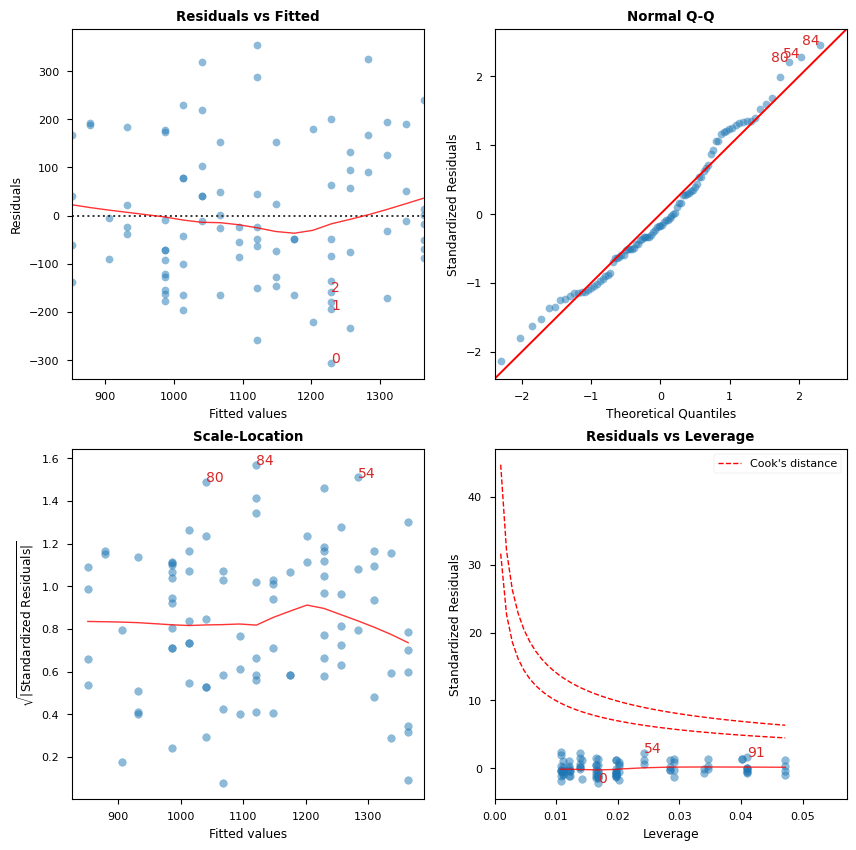

        Features  VIF Factor
1  Weight_carats        1.00
0      Intercept       58.39


In [114]:
fig, ax = cls()
#fig.savefig('../../docs/source/_static/images/linear_regression_diagnostics_plots.png')

## Below is step-by-step for Multiple Linear Regression diagnostics, for reference later

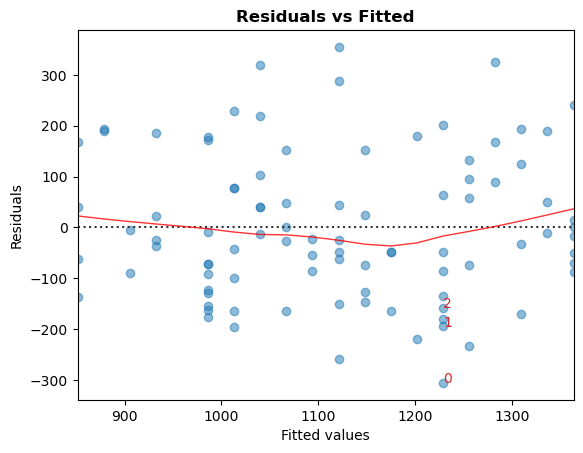

In [117]:
# Residual vs Fitted values
# Graphical tool to identify non-linearity.
# In the graph red (roughly) horizontal line is an indicator that the residual has a linear pattern.
cls.residual_plot();

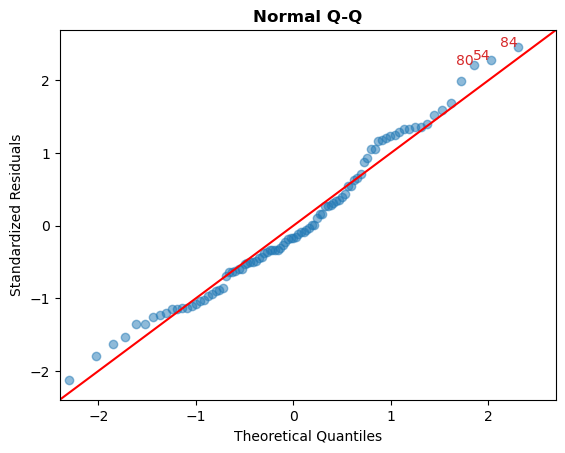

In [119]:
# Standarized Residual vs Theoretical Quantile
# This plot is used to visually check if residuals are normally distributed.
# Points spread along the diagonal line will suggest so.
cls.qq_plot()
plt.show()

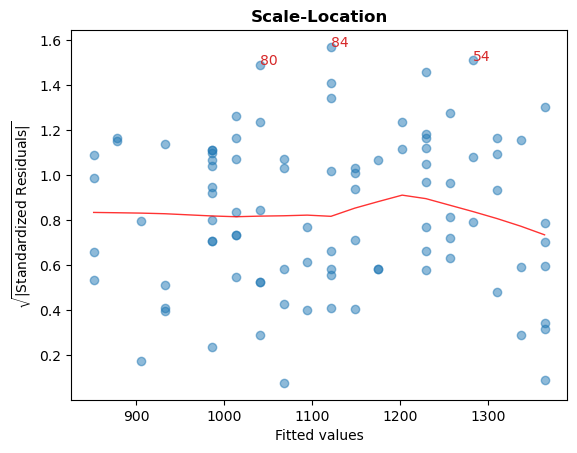

In [121]:
# Sqrt(Standarized Residual) vs Fitted values
# This plot is used to check homoscedasticity of the residuals.
# A near horizontal red line in the graph would suggest so.
cls.scale_location_plot()
plt.show()

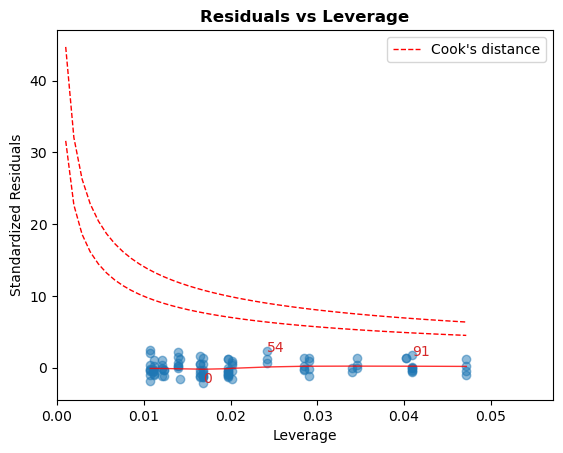

In [123]:
# Residual vs Leverage
# Points falling outside the Cook’s distance curves are considered observation that can sway the fit aka are influential.
# Good to have no points outside these curves.
cls.leverage_plot()
plt.show()

## The variance inflation factor (<b>VIF</b>), is a measure of multicollinearity.
## VIF > 5 for a variable indicates that it is highly collinear with the other input variables.

In [126]:
cls.vif_table()
plt.show()

        Features  VIF Factor
1  Weight_carats        1.00
0      Intercept       58.39


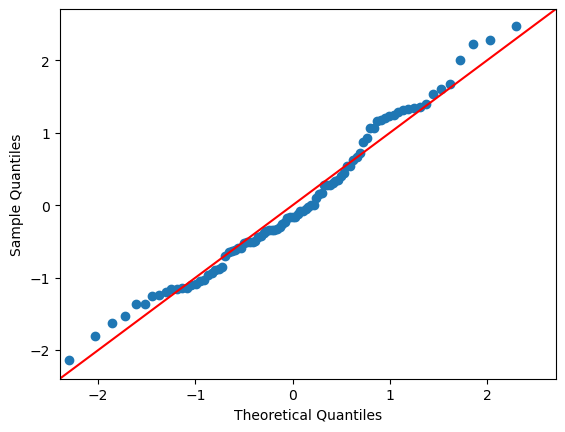

In [128]:
# Q-Q plot of the quantiles of residual versus the quantiles/ppf of t distribution, similar to a normal distribution.
import scipy.stats as stats
res = diamonds_lm.resid # residuals
fig = sm.qqplot(res, stats.t, fit=True, line="45")
plt.show()